# 02 — Process Performance Map (Camargo Helpdesk)

Port of the henryk `02_process_performance_map` notebook, adapted for the Camargo `SharedCat_LSTM` baseline trained with the **paper-faithful n-gram=5 loader** (see `train_camargo_LSTM_sharedcat_roles.ipynb`). The earlier U-ED-LSTM-style windowing gave the model no signal at short prefixes — this variant emits one training sample per time-step with the actual next activity as target.

- **Node label**: activity; color ∝ overall per-source-activity accuracy.
- **Edge label**: `correct / total` predictions for that directly-follows transition.
- **Edge color**: per-transition accuracy (green = high, red = low).

The Camargo model is a single-step next-activity predictor; we iterate prefixes (length 1..L-1) and call it once per prefix to build the performance map.

In [2]:
import sys
from pathlib import Path

# Locate project root and add needed paths
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
SPEC = utils.HELPDESK_SHAREDCAT_ROLES_NGRAM

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
# With ngram_size set, use that at inference so the input shape matches training.
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
print(f'Loaded Camargo {SPEC.name} model | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Role', 9, {'EOS': 1, 'Role_1': 2, 'Role_2': 3, 'Role_3': 4, 'Role_4': 5, 'Role_5': 6, 'Role_6': 7, 'Role_7': 8})], [('case_elapsed_time', 1, {})])
Model input features:  [['Activity', 'Role'], ['case_elapsed_time']]
Embeddings:  ModuleList(
  (0): Embedding(16, 8)
  (1): Embedding(9, 5)
)
Total embedding feature size:  13
Number of numerical features:  1
Input feature size (shared LSTM, cat-only):  13
Cells hidden size:  50
Number of LSTM layer:  1


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Loaded Camargo Helpdesk model | window=5 | vocab=16 classes | |test|=6077


In [3]:
records = utils.collect_prefix_predictions(predictor, dataset, progress=True, include_end=True)
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")

Collected 4245 prefix predictions
Overall accuracy: 84.6%


In [4]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'confidence' in records[0]:
    mean_conf = sum(r['confidence'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 3590/4245 = 0.8457 (84.57%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1      770    916  0.840611
             2      663    916  0.723799
             3      768    916  0.838428
             4      823    878  0.937358
             5      328    357  0.918768
             6      135    148  0.912162
             7       60     66  0.909091
             8       26     29  0.896552
             9       10     12  0.833333
            10        4      4  1.000000
            11        2      2  1.000000
            12        1      1  1.000000

Mean top-1 confidence: 84.66%


In [5]:
import pandas as pd
from collections import defaultdict

# Per-transition stats (source activity, actual next activity) -> total / correct
stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['actual_next_activity'])
    stats[key]['total'] += 1
    stats[key]['correct'] += int(r['correct'])

# Per-source accuracy (node color)
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = []
for (src, tgt), s in stats.items():
    rows.append({'source': src, 'target': tgt, 'correct': s['correct'], 'total': s['total'],
                 'accuracy': s['correct'] / s['total']})
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)

44 unique transitions


,source,target,correct,total,accuracy
0,Assign seriousness,Take in charge ticket,835,837,0.997611
6,Assign seriousness,Assign seriousness,1,96,0.010417
11,Assign seriousness,Resolve ticket,0,50,0.000000
16,Assign seriousness,Wait,0,11,0.000000
31,Assign seriousness,Require upgrade,0,1,0.000000
3,Closed,EOS,910,910,1.000000
18,Closed,Closed,0,5,0.000000
25,Closed,Take in charge ticket,0,1,0.000000
27,Create SW anomaly,Resolve ticket,7,8,0.875000
29,Create SW anomaly,Require upgrade,0,2,0.000000


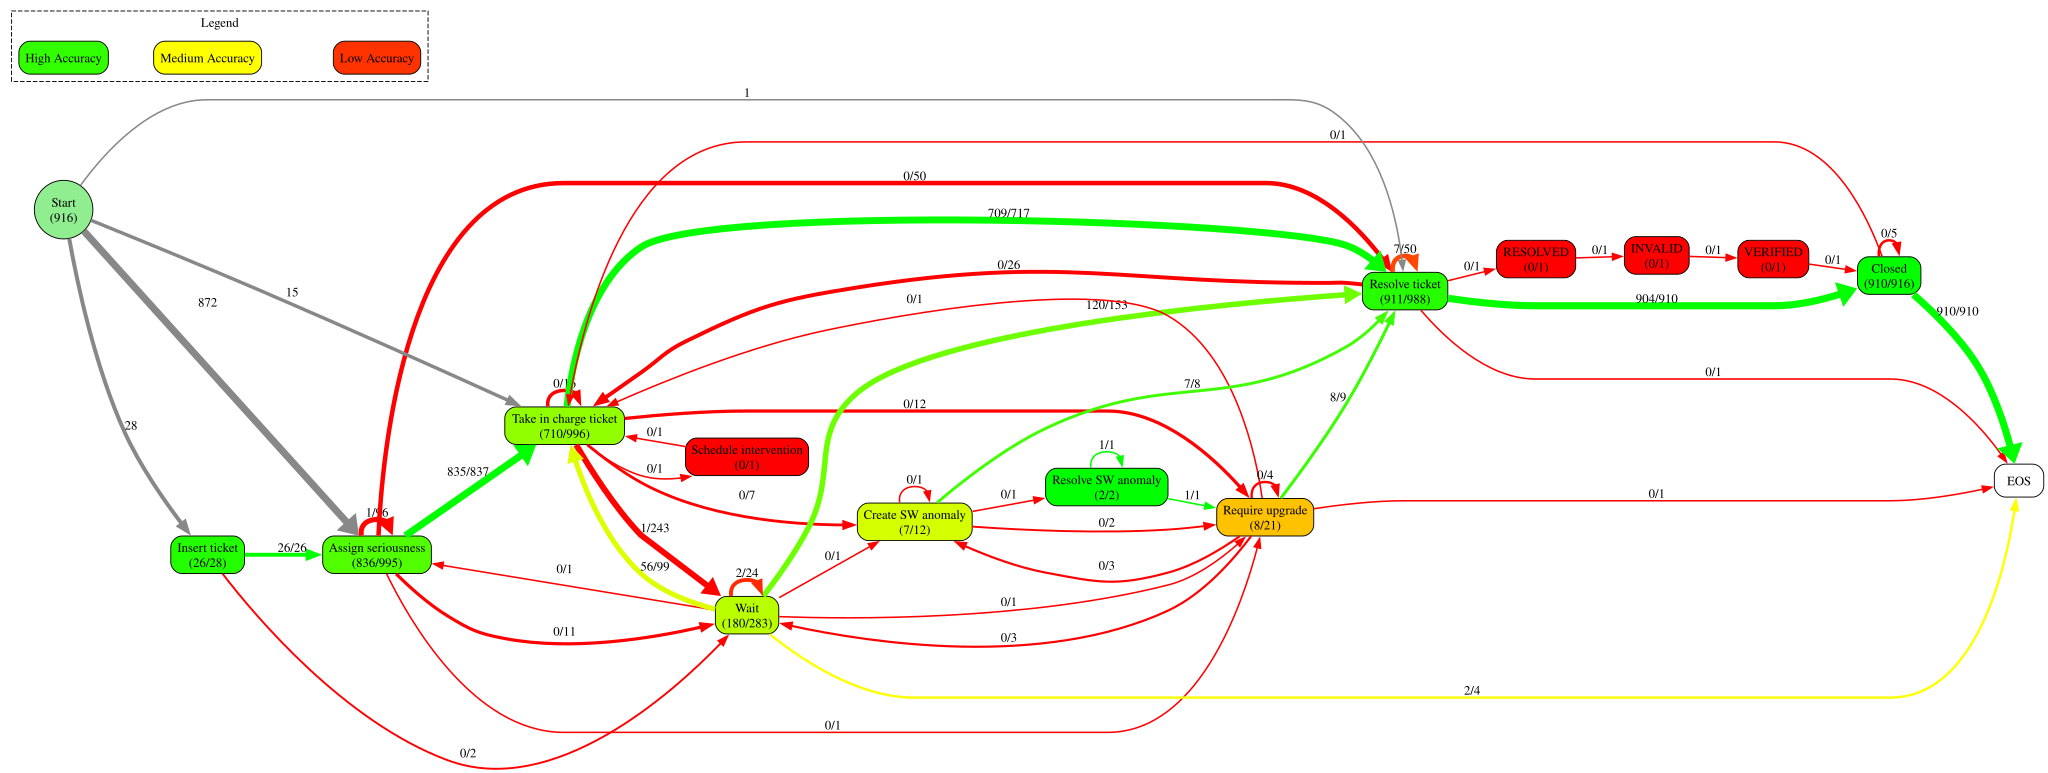

In [6]:
import graphviz
import math

MIN_EDGE_COUNT = 0

def get_color_for_accuracy(accuracy: float) -> str:
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} Process Performance Map')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

# Activity nodes
for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act)
        fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

# Start node (first activity of each case)
start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(1 + math.log1p(cnt)))

# Transition edges
for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f"{s['correct']}/{s['total']}"
    dot.edge(str(src), str(tgt), label=label, color=color,
             penwidth=str(1 + math.log1p(s['total'])))

# Legend (same layout as henryk)
with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [7]:
# Per-source summary
print('Per-source-activity accuracy:')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy:
  Take in charge ticket            710/996     71.3%
  Assign seriousness               836/995     84.0%
  Resolve ticket                   911/988     92.2%
  Closed                           910/916     99.3%
  Wait                             180/283     63.6%
  Insert ticket                     26/28      92.9%
  Require upgrade                    8/21      38.1%
  Create SW anomaly                  7/12      58.3%
  Resolve SW anomaly                 2/2      100.0%
  Schedule intervention              0/1        0.0%
  RESOLVED                           0/1        0.0%
  INVALID                            0/1        0.0%
  VERIFIED                           0/1        0.0%
